# Titanic Exploratory Data Analysis (EDA)

## Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load the Titanic Dataset

Load the dataset into a pandas DataFrame and display the first five rows.

## Dataset Metadata

Each row represents one passenger. `Survived` is the outcome (`0` = did not survive, `1` = survived). `Pclass` records ticket class (`1` = first, `2` = second, `3` = third); `Sex` and `Age` describe the passenger; `SibSp` and `Parch` count relatives aboard; `Fare` records the ticket fare; `Cabin` records a cabin identifier when available; and `Embarked` identifies the boarding port (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton). `PassengerId`, `Name`, and `Ticket` are identifiers rather than direct survival measures.

In [3]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Explore the Dataset

Examine the dataset structure, summary statistics, and missing values.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.info())

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Summary Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Data Cleaning

The initial inspection found missing values in `Age`, `Cabin`, and `Embarked`. Cleaning is completed before analysing survival so that age-based comparisons include every passenger and missing values do not silently affect the results.

- `Age` is filled with the median age within each passenger-class and sex group; this preserves meaningful differences between groups better than one overall median.
- `Embarked` has only two missing values, so it is filled with the most common port.
- `Cabin` is missing for most passengers. Instead of inventing cabin numbers, a `HasCabin` indicator keeps the useful information about whether a cabin was recorded, then the sparse raw column is removed.
- Duplicate records are checked and removed if present.

In [10]:
# Reloading makes this preprocessing cell safe to run repeatedly.
df = pd.read_csv("Titanic.csv")

# Remove any duplicate passenger records before filling missing values.
duplicate_rows = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Impute age within comparable class and sex groups.
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda ages: ages.fillna(ages.median())
)

# Fill the two missing embarkation values with the dataset's modal port.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Retain cabin-record availability without fabricating missing cabin identifiers.
df["HasCabin"] = df["Cabin"].notna()
df = df.drop(columns="Cabin")

print(f"Duplicate rows removed: {duplicate_rows}")
print("\nMissing values after cleaning:")
print(df.isnull().sum())
assert df.isnull().sum().sum() == 0, "Cleaning did not resolve all missing values."
df.head()

Duplicate rows removed: 0

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,False


## Overall Survival

This chart shows how many passengers survived versus those who did not.

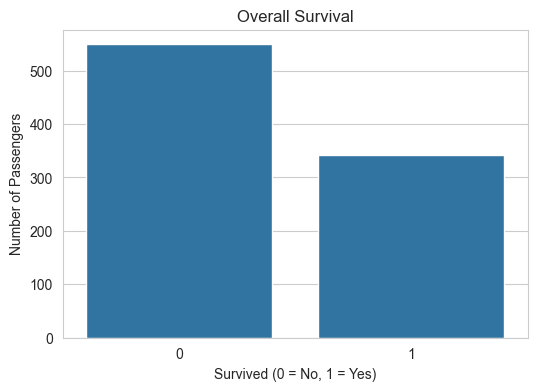

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived")
plt.title("Overall Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

# Question 1
## What is the most important factor in determining whether a person survived?

We will compare survival by gender.

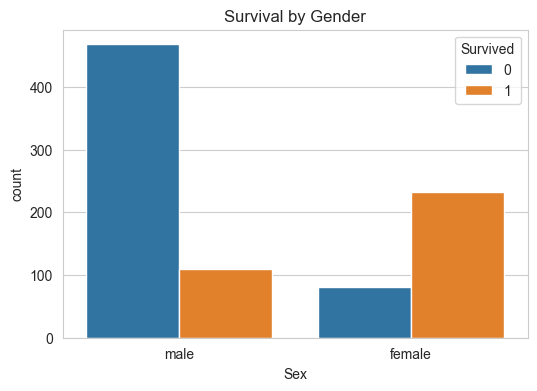

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

In [6]:
print("Survival Rate by Gender")
print(df.groupby("Sex")["Survived"].mean() * 100)

Survival Rate by Gender
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [5]:
# Compare unadjusted survival rates for the main candidate factors.
for column in ["Sex", "Pclass", "Embarked", "HasCabin"]:
    print(f"\nSurvival rate by {column} (%)")
    display((df.groupby(column, observed=False)["Survived"].mean() * 100).round(1))


Survival rate by Sex (%)


Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


Survival rate by Pclass (%)


Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


Survival rate by Embarked (%)


Embarked
C    55.4
Q    39.0
S    33.9
Name: Survived, dtype: float64


Survival rate by HasCabin (%)


HasCabin
False    30.0
True     66.7
Name: Survived, dtype: float64

### Observation

Sex shows the largest unadjusted survival-rate gap: female passengers survived far more often than male passengers. Passenger class and having a recorded cabin also show sizeable differences, so they are important related factors. These comparisons describe associations in this passenger list; they do not prove that any single feature caused survival.

# Question 2
## Were upper-class passengers given preference on the lifeboats?

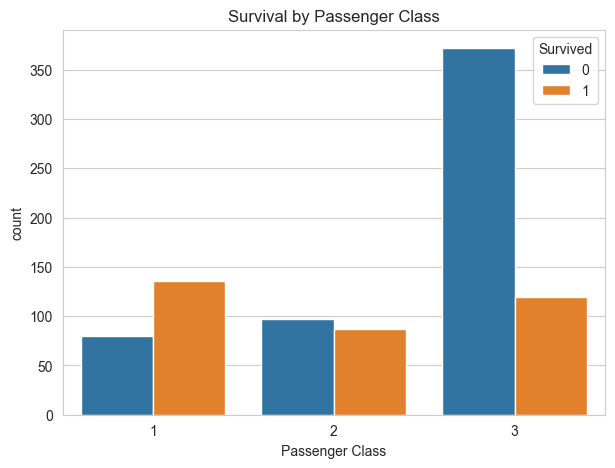

In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.show()

In [8]:
print("Survival Rate by Passenger Class")
print(df.groupby("Pclass")["Survived"].mean() * 100)

Survival Rate by Passenger Class
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


### Observation

First-class passengers had the highest observed survival rate, followed by second class and then third class. This pattern is consistent with upper-class passengers having greater access to lifeboats, although this observational dataset alone cannot establish why the difference occurred.

# Question 3
## "Women and children first"

We create a new column identifying children (under 18 years old).

In [6]:
# Age is complete after cleaning, so every passenger can be classified consistently.
df["Child"] = df["Age"] < 18

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 18, 65, float("inf")],
    labels=["Child (under 18)", "Adult (18-64)", "Senior (65+)",],
    right=False,
)

In [7]:
priority_rates = (
    df.groupby(["Sex", "AgeGroup"], observed=False)["Survived"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "survival_rate", "size": "passengers"})
)
priority_rates["survival_rate"] = (priority_rates["survival_rate"] * 100).round(1)
priority_rates

survival_rate  passengers
Sex    AgeGroup                                   
female Child (under 18)           69.1          55
       Adult (18-64)              75.3         259
       Senior (65+)                NaN           0
male   Child (under 18)           39.7          58
       Adult (18-64)              16.7         508
       Senior (65+)                9.1          11

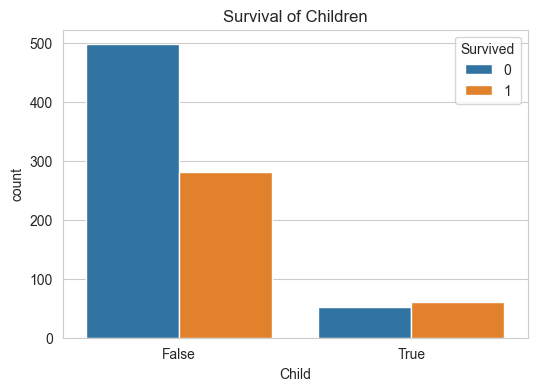

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Child", hue="Survived")
plt.title("Survival of Children")
plt.show()

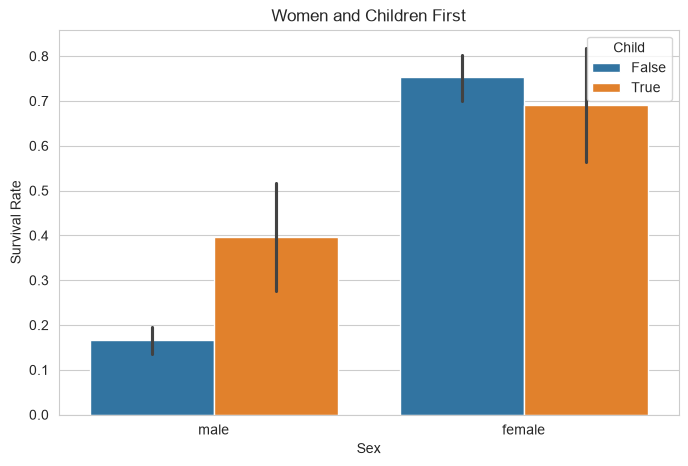

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Sex", y="Survived", hue="Child")
plt.title("Women and Children First")
plt.ylabel("Survival Rate")
plt.show()

In [12]:
print("Survival Rate by Child")
print(df.groupby("Child")["Survived"].mean() * 100)

Survival Rate by Child
Child
False    36.118252
True     53.982301
Name: Survived, dtype: float64


### Observation

The combined table and chart let us compare women, men, and children rather than treating them as one group. Women, including adult women, had much higher survival rates than men. Children also survived more often than adults overall, but the combined results show that sex remained a very strong distinction within the age groups. The evidence is consistent with the "women and children first" account, while acknowledging that it records outcomes rather than the lifeboat-allocation decisions themselves.

# Additional Observation

Passengers who paid higher fares appeared to survive more frequently.

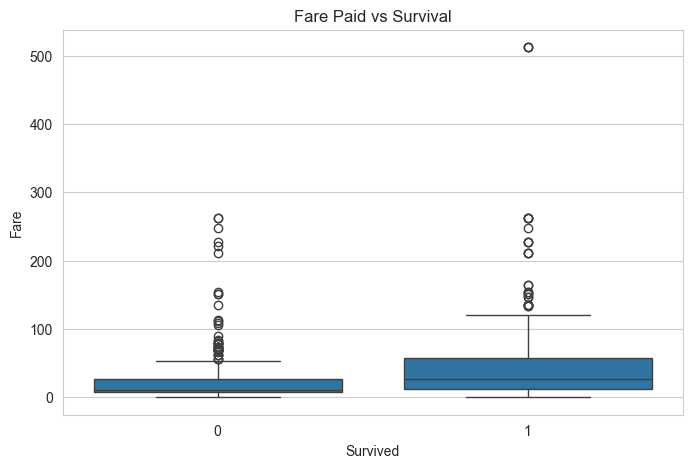

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare Paid vs Survival")
plt.show()

In [14]:
print("Average Fare Paid")
print(df.groupby("Survived")["Fare"].mean())

Average Fare Paid
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


### Observation

Passengers who survived generally paid higher fares.

This is likely because higher fares were associated with first-class cabins, which had better access to lifeboats.

# Correlation Between Numerical Variables

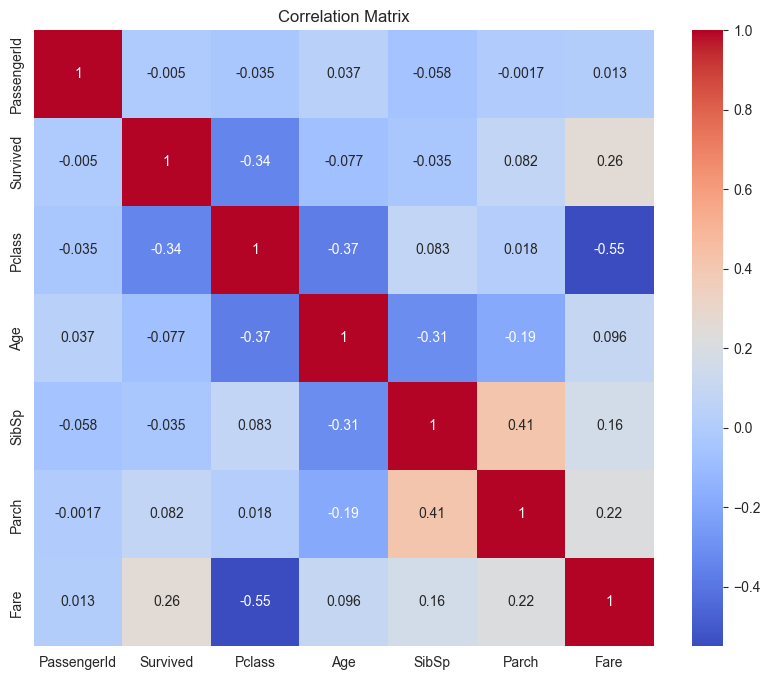

In [15]:
numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Final Conclusions

### What was the most important factor in determining survival?

In this dataset, sex is the strongest unadjusted factor examined: 74.2% of female passengers survived compared with 18.9% of male passengers, a gap of about 55 percentage points. Passenger class and cabin-record availability also had large associations with survival, so survival should not be attributed to one characteristic alone.

### Were upper-class passengers given preference?

First-class passengers had the highest observed survival rate (63.0%), followed by second class (47.3%) and third class (24.2%). The pattern is consistent with an upper-class advantage, but the data describes survival outcomes and cannot by itself prove the lifeboat decisions that produced them.

### Was "women and children first" supported?

The results strongly support a survival advantage for women. Female children survived at 69.1% and adult women at 75.3%, compared with 39.7% for male children and 16.7% for adult men. Children had better outcomes than adult men, but the strong gap between female and male children shows that sex was especially influential.

### Additional Observation

Passengers who survived paid a higher average fare than those who did not. Since fares were closely related to passenger class, this likely reflects the same socioeconomic advantage seen in the class analysis rather than a separate causal effect of fare.

### Data Quality Note

Before analysis, duplicate rows were checked, ages were imputed using the median within passenger-class and sex groups, the two missing embarkation values were filled with the modal port, and the sparse cabin column was converted to a `HasCabin` feature. The post-cleaning audit confirmed that the analytical DataFrame has no remaining missing values.